# data exploration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from time import time
import random

import tensorflow as tf
from sklearn.preprocessing import OneHotEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

In [ ]:
data = pd.read_csv('bank_data_prediction_task.csv', index_col = 0)

C:\Users\mbulk\AppData\Roaming\Python\Python37\site-packages\IPython\core\interactiveshell.py:3170: DtypeWarning: Columns (8,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


In [ ]:
data.iloc[:5, :15]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome
1,37,services,married,high.school,no,yes,no,telephone,may,mon,226.0,1.0,999,0,nonexistent
2,56,services,married,high.school,no,no,yes,telephone,may,mon,307.0,1.0,999,0,nonexistent
3,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,217.0,1.0,999,0,nonexistent
4,25,services,single,high.school,no,yes,no,telephone,may,mon,50.0,1.0,999,0,nonexistent
5,25,services,single,high.school,no,yes,no,telephone,may,mon,222.0,1.0,999,0,nonexistent


In [ ]:
data.iloc[:5, 15:]

,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,test_control_flag
1,1.1,93.994,-36.4,4.857,5191.0,no,campaign group
2,1.1,93.994,-36.4,4.857,5191.0,no,campaign group
3,1.1,93.994,-36.4,4.857,5191.0,yes,campaign group
4,1.1,93.994,-36.4,4.857,5191.0,no,campaign group
5,1.1,93.994,-36.4,4.857,5191.0,no,campaign group


In [ ]:
data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'test_control_flag'],
      dtype='object')

Explanations of some terms:  
emp.var.rate- how big is a change in employement (how many people get hired or fired)  
consumer price index - how big is a change in how much money customers spend  
consumer confidence index- how pesimistic or optimistic people are about their financial situation in the nearest future  
euribor 3 month rate- 3 month rate at which banks borrow funds in euros from one another. If this rate is low then then people pay less for their loans so it is beneficial for them.

calculating chi squared. If chi squared is smaller than 0.05 then given feature is correlated with the 'y' variable

In [ ]:
ChiSqResults = []

for column in [
    'age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
    'contact', 'month', 'day_of_week', 'duration', 'campaign','poutcome'
]:
    CrosstabResult = pd.crosstab(index = data[column], columns = data['y'])
    ChiSqResults.append([column, chi2_contingency(CrosstabResult)[1]])
    
df = pd.DataFrame(ChiSqResults, columns = ['feature', 'chi_squared'])
df.sort_values(by = 'chi_squared')

,feature,chi_squared
12,poutcome,0.000000e+00
10,duration,7.992084e-247
0,age,3.334413e-232
1,job,2.777061e-144
8,month,3.802114e-115
4,default,9.439545e-70
2,marital,2.397748e-59
7,contact,2.220714e-36
3,education,3.935600e-18
6,loan,2.440140e-03


calculating correlation for numerical variables

In [ ]:
corr = np.array([])
for column in [
    'pdays', 'previous', 'emp.var.rate', 'cons.price.idx',
    'cons.conf.idx', 'euribor3m', 'nr.employed'
]:
    df = data[[column, 'y']].dropna()
    y = df['y'].apply(lambda x: 1 if x == 'yes' else 0).values
    x = df[column].values
    if len(corr) == 0:
        corr = np.array([[column, np.corrcoef(x, y)[0,1]]])
    else:
        corr = np.concatenate((corr, [[column, np.corrcoef(x, y)[0,1]]]), axis = 0)

In [ ]:
pd.DataFrame(corr, columns = ['feature', 'correlation_with_y']).sort_values(by = 'correlation_with_y')

,feature,correlation_with_y
3,cons.price.idx,-0.11191057015917759
2,emp.var.rate,-0.255561940750331
5,euribor3m,-0.2651695899608683
0,pdays,-0.2807193683123893
6,nr.employed,-0.3066371412555699
4,cons.conf.idx,0.044016678896950295
1,previous,0.20543292917077963


It looks like all the variables are correlated with the 'y' variable except for 'day_of_week', 'cons.conf.idx' and 'cons.price.idx'

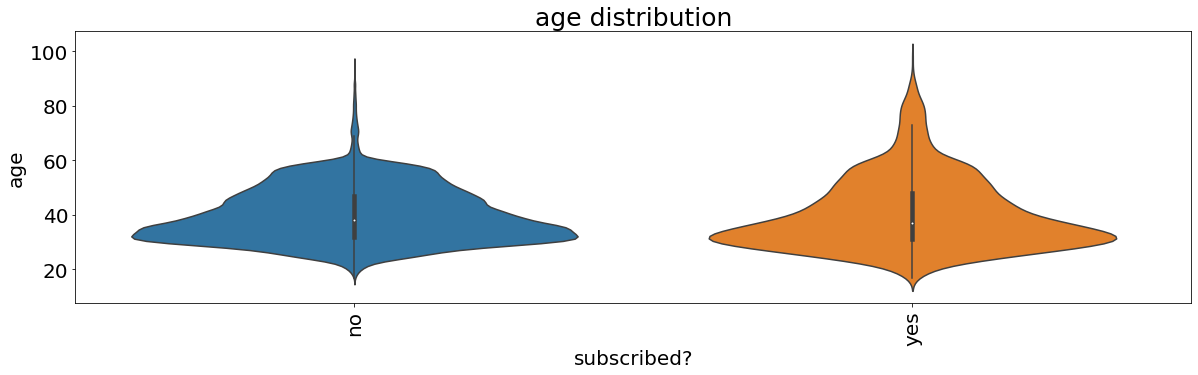

In [ ]:
fig, ax = plt.subplots(figsize = (20, 5))
sns.violinplot(data = data, y = 'age', x = 'y')
plt.xticks(rotation=90)
plt.title('age distribution', fontsize = 25)
plt.ylabel('age', fontsize = 20)
plt.xlabel('subscribed?', fontsize = 20)
ax.tick_params(axis='both', labelsize = 20)

C:\Users\mbulk\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.


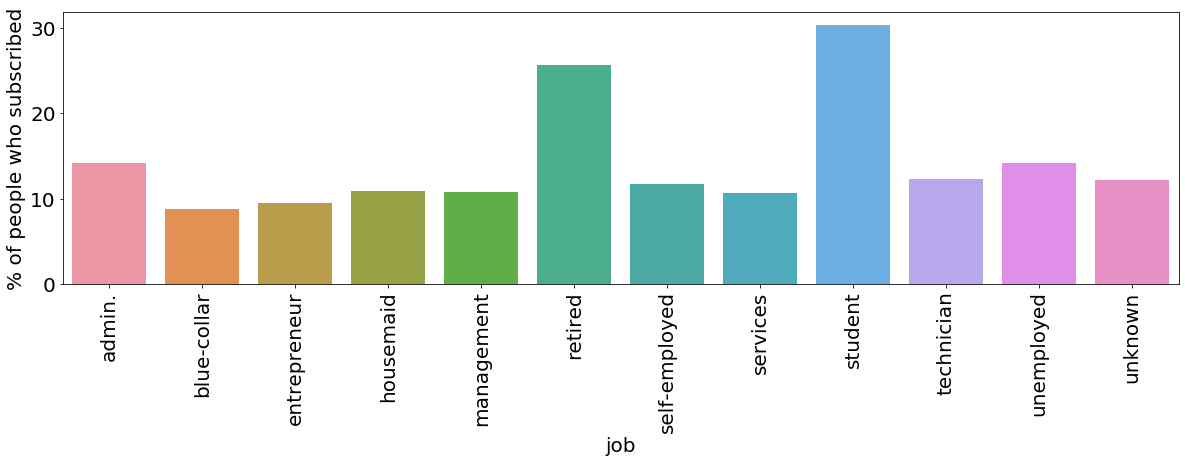

In [ ]:
column = 'job'

df = data[['y', column]]
df['y'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)
df = df.groupby(column).mean().reset_index()
df['y'] = df['y'].apply(lambda x: x * 100)

fig, ax = plt.subplots(figsize = (20, 5))
sns.barplot(data = df, x = column, y = 'y')
plt.xticks(rotation = 90)
plt.ylabel('% of people who subscribed', fontsize = 20)
plt.xlabel(column, fontsize = 20)
ax.tick_params(axis='both', labelsize = 20)

C:\Users\mbulk\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.


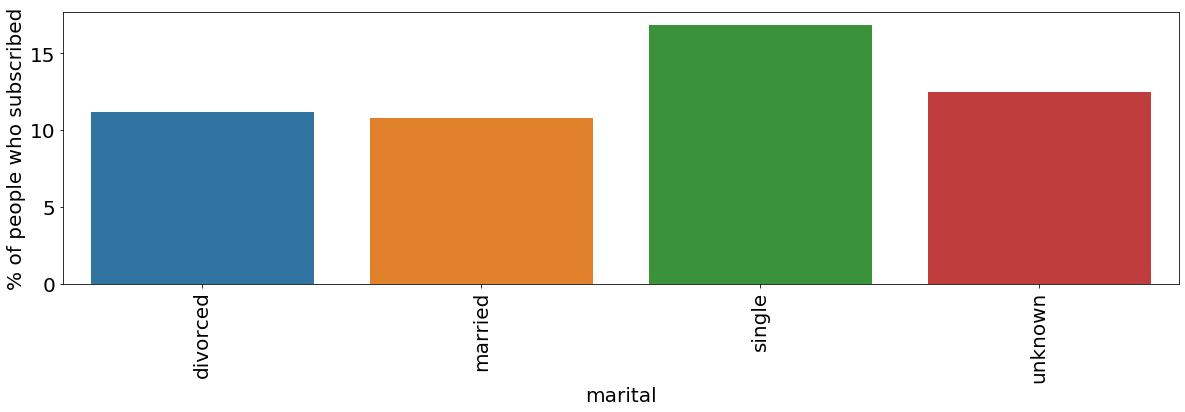

In [ ]:
column = 'marital'

df = data[['y', column]]
df['y'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)
df = df.groupby(column).mean().reset_index()
df['y'] = df['y'].apply(lambda x: x * 100)

fig, ax = plt.subplots(figsize = (20, 5))
sns.barplot(data = df, x = column, y = 'y')
plt.xticks(rotation = 90)
plt.ylabel('% of people who subscribed', fontsize = 20)
plt.xlabel(column, fontsize = 20)
ax.tick_params(axis='both', labelsize = 20)

C:\Users\mbulk\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.


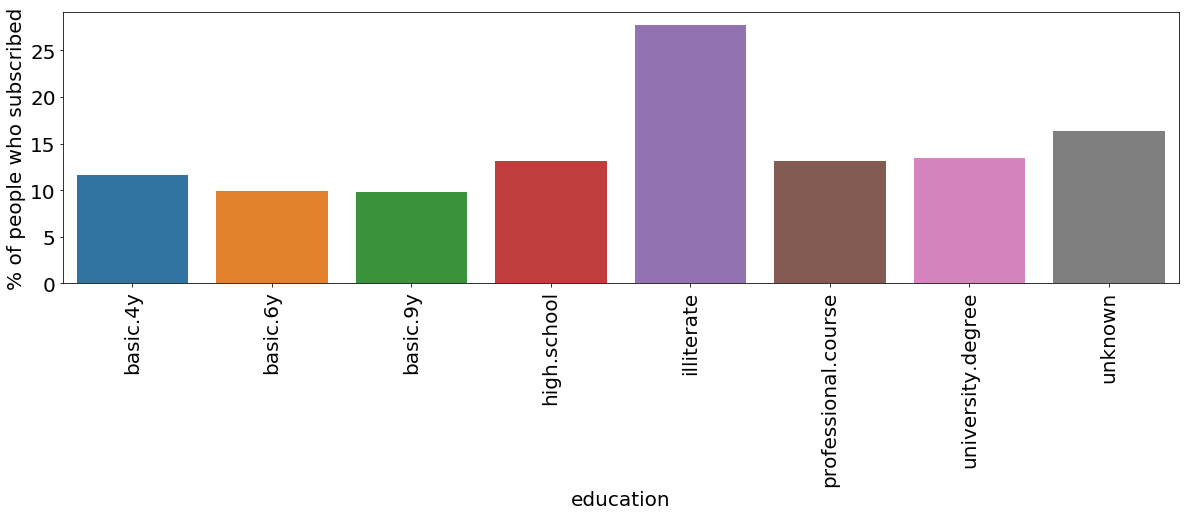

In [ ]:
column = 'education'

df = data[['y', column]]
df['y'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)
df = df.groupby(column).mean().reset_index()
df['y'] = df['y'].apply(lambda x: x * 100)

fig, ax = plt.subplots(figsize = (20, 5))
sns.barplot(data = df, x = column, y = 'y')
plt.xticks(rotation = 90)
plt.ylabel('% of people who subscribed', fontsize = 20)
plt.xlabel(column, fontsize = 20)
ax.tick_params(axis='both', labelsize = 20)

C:\Users\mbulk\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.


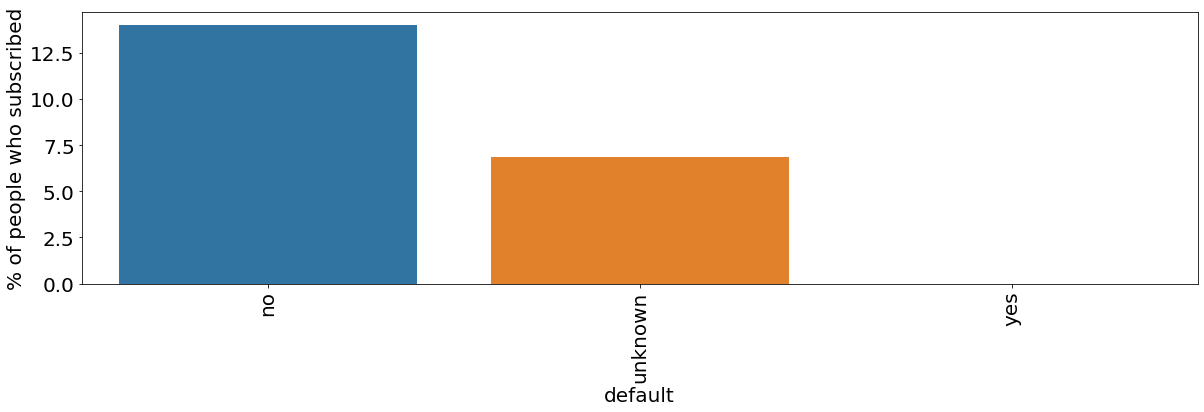

In [ ]:
column = 'default'

df = data[['y', column]]
df['y'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)
df = df.groupby(column).mean().reset_index()
df['y'] = df['y'].apply(lambda x: x * 100)

fig, ax = plt.subplots(figsize = (20, 5))
sns.barplot(data = df, x = column, y = 'y')
plt.xticks(rotation = 90)
plt.ylabel('% of people who subscribed', fontsize = 20)
plt.xlabel(column, fontsize = 20)
ax.tick_params(axis='both', labelsize = 20)

contact


C:\Users\mbulk\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """


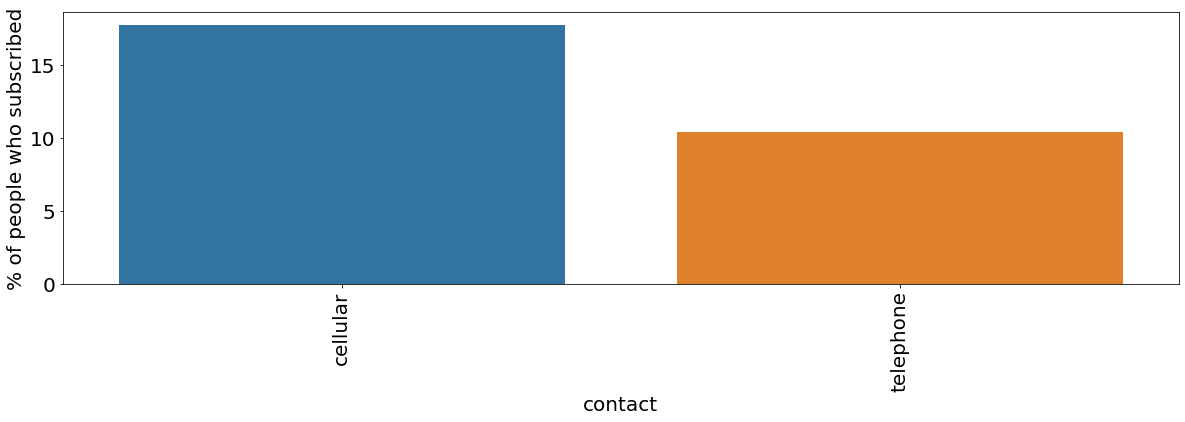

In [ ]:
column = data.columns[7]
print(column)

df = data[['y', column]]
df['y'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)
df = df.groupby(column).mean().reset_index()
df['y'] = df['y'].apply(lambda x: x * 100)

fig, ax = plt.subplots(figsize = (20, 5))
sns.barplot(data = df, x = column, y = 'y')
plt.xticks(rotation = 90)
plt.ylabel('% of people who subscribed', fontsize = 20)
plt.xlabel(column, fontsize = 20)
ax.tick_params(axis='both', labelsize = 20)

month


C:\Users\mbulk\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """


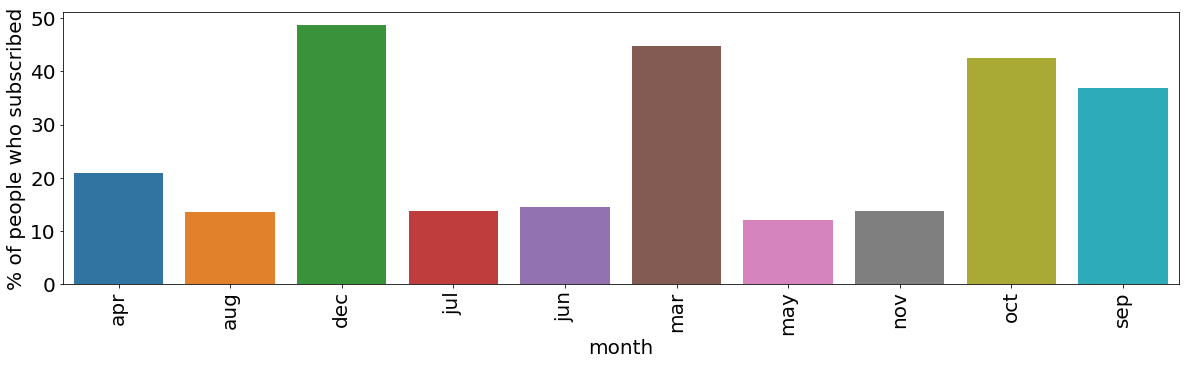

In [ ]:
column = data.columns[8]
print(column)

df = data[['y', column]]
df['y'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)
df = df.groupby(column).mean().reset_index()
df['y'] = df['y'].apply(lambda x: x * 100)

fig, ax = plt.subplots(figsize = (20, 5))
sns.barplot(data = df, x = column, y = 'y')
plt.xticks(rotation = 90)
plt.ylabel('% of people who subscribed', fontsize = 20)
plt.xlabel(column, fontsize = 20)
ax.tick_params(axis='both', labelsize = 20)

nr.employed


C:\Users\mbulk\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


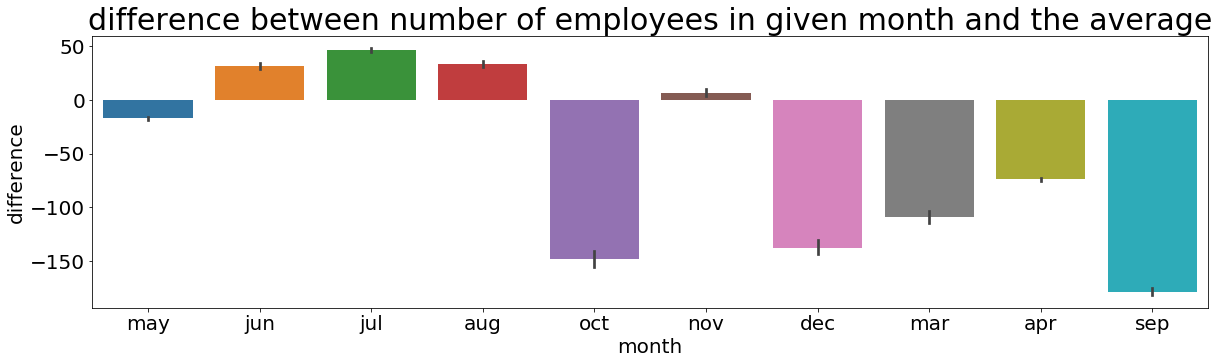

In [ ]:
column = data.columns[19]
print(column)

df = data[['month', column]]

avg = data[column].mean()

df[column] = df[column].apply(lambda x: x - avg)

fig, ax = plt.subplots(figsize = (20, 5))
sns.barplot(data = df, y = column, x = 'month')
# plt.plot(df['month'], df[column])
# plt.xticks(rotation = 90)
plt.title('difference between number of employees in given month and the average', fontsize = 30)
plt.ylabel('difference', fontsize = 20)
plt.xlabel('month', fontsize = 20)
ax.tick_params(axis='both', labelsize = 20)

the fact that in some months the campaign was more successful might have been caused by the fact that in those months employement was higher or lower because it was the same as in the other months

duration


C:\Users\mbulk\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """


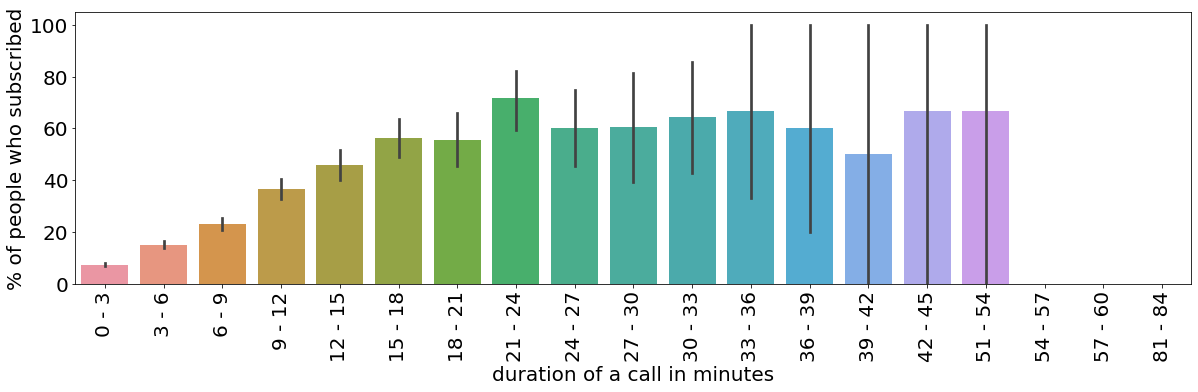

In [ ]:
column = data.columns[10]
print(column)

df = data[['y', column]]
df['y'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)
df = df.groupby(column).mean().reset_index()
df['y'] = df['y'].apply(lambda x: x * 100)

# assign range into a value. 
# For example if value = 3 and range_length = 5 then this function returns string '0 - 5'.
# if value = 6 and range_length = 5 then this function returns string '5 - 10'.
def assign_range(value, range_length):
    i = 0
    while i < value:
        i += range_length
    if i > 0:
        return f'{(i - range_length) // 60} - {i // 60}'
    else:
        return f'{i // 60} - {(i + range_length) // 60}'
    
df[column] = df[column].apply(lambda x: assign_range(x, 180))

fig, ax = plt.subplots(figsize = (20, 5))
sns.barplot(data = df, x = column, y = 'y')
plt.xticks(rotation = 90)
plt.ylabel('% of people who subscribed', fontsize = 20)
plt.xlabel('duration of a call in minutes', fontsize = 20)
ax.tick_params(axis='both', labelsize = 20)

campaign


C:\Users\mbulk\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """


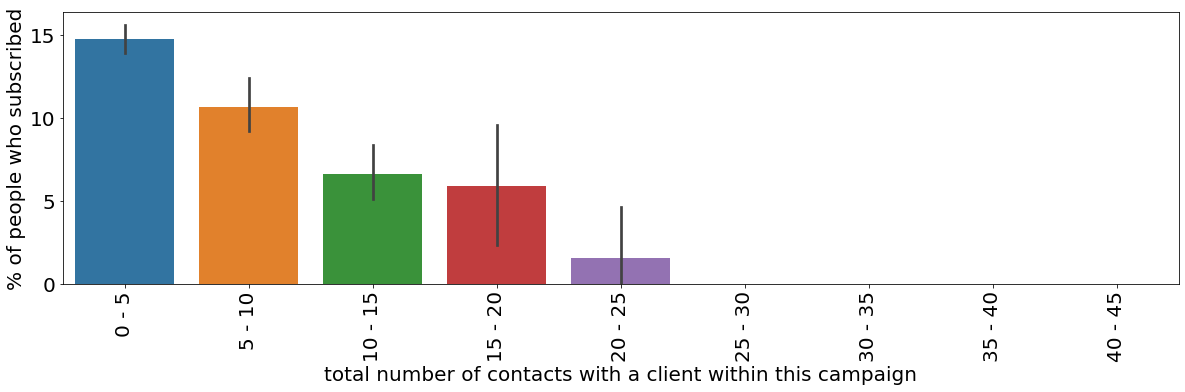

In [ ]:
column = data.columns[11]
print(column)

df = data[['y', column]]
df['y'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)
df = df.groupby(column).mean().reset_index()
df['y'] = df['y'].apply(lambda x: x * 100)

# assign range into a value. 
# For example if value = 3 and range_length = 5 then this function returns string '0 - 5'.
# if value = 6 and range_length = 5 then this function returns string '5 - 10'.
def assign_range(value, range_length):
    i = 0
    while i < value:
        i += range_length
    if i > 0:
        return f'{i - range_length} - {i}'
    else:
        return f'{i} - {i + range_length}'
    
df[column] = df[column].apply(lambda x: assign_range(x, 5))

fig, ax = plt.subplots(figsize = (20, 5))
sns.barplot(data = df, x = column, y = 'y')
plt.xticks(rotation = 90)
plt.ylabel('% of people who subscribed', fontsize = 20)
plt.xlabel('total number of contacts with a client within this campaign', fontsize = 20)
ax.tick_params(axis='both', labelsize = 20)

pdays


C:\Users\mbulk\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """


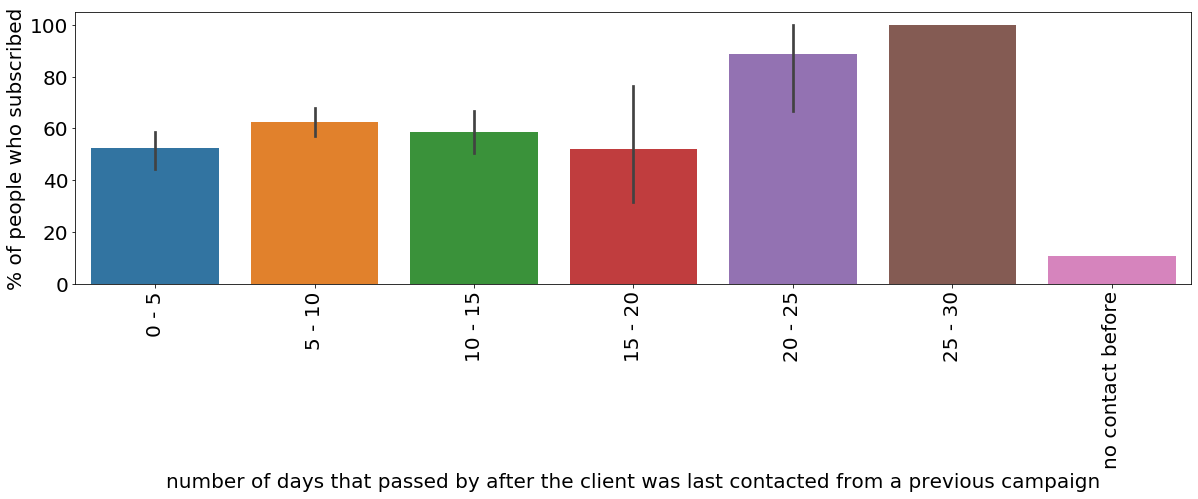

In [ ]:
column = data.columns[12]
print(column)

df = data[['y', column]]
df['y'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)
df = df.groupby(column).mean().reset_index()
df['y'] = df['y'].apply(lambda x: x * 100)

# assign range into a value. 
# For example if value = 3 and range_length = 5 then this function returns string '0 - 5'.
# if value = 6 and range_length = 5 then this function returns string '5 - 10'.
def assign_range(value, range_length):
    if value == 999:
        return 'no contact before'
    
    i = 0
    while i < value:
        i += range_length
    if i > 0:
        return f'{i - range_length} - {i}'
    else:
        return f'{i} - {i + range_length}'
    
df[column] = df[column].apply(lambda x: assign_range(x, 5))

fig, ax = plt.subplots(figsize = (20, 5))
sns.barplot(data = df, x = column, y = 'y')
plt.xticks(rotation = 90)
plt.ylabel('% of people who subscribed', fontsize = 20)
plt.xlabel('number of days that passed by after the client was last contacted from a previous campaign', fontsize = 20)
ax.tick_params(axis='both', labelsize = 20)

previous


c:\python\python37\lib\site-packages\pandas\core\indexing.py:494: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[item] = s


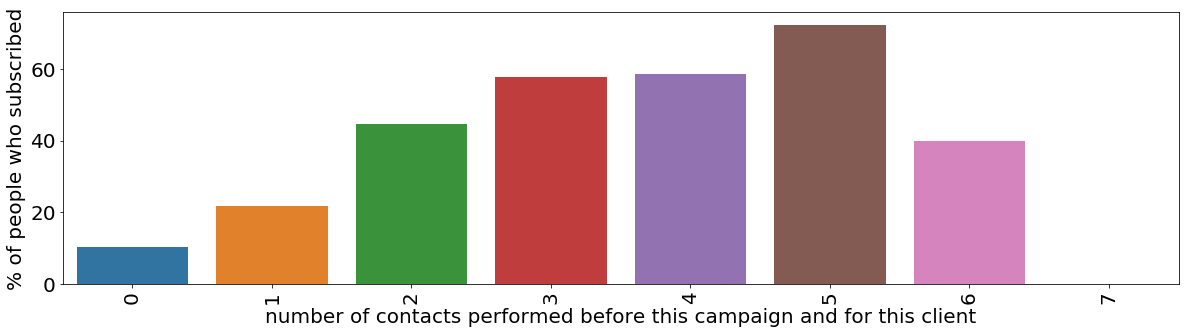

In [ ]:
column = data.columns[13]
print(column)

df = data[['y', column]]
df.loc[:, 'y'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)
df = df.groupby(column).mean().reset_index()
df.loc[:, 'y'] = df['y'].apply(lambda x: x * 100)

fig, ax = plt.subplots(figsize = (20, 5))
sns.barplot(data = df, x = column, y = 'y')
plt.xticks(rotation = 90)
plt.ylabel('% of people who subscribed', fontsize = 20)
plt.xlabel('number of contacts performed before this campaign and for this client', fontsize = 20)
ax.tick_params(axis='both', labelsize = 20)

poutcome


C:\Users\mbulk\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """


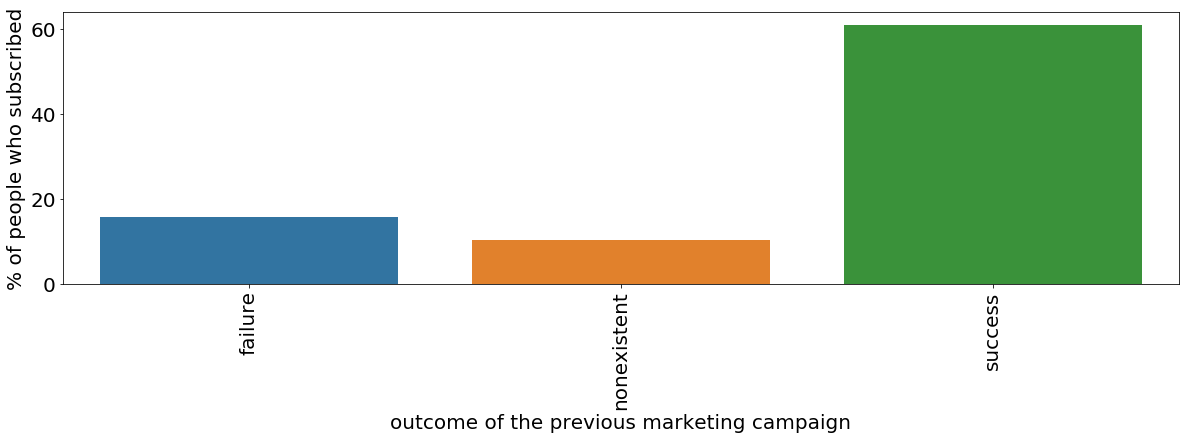

In [ ]:
column = data.columns[14]
print(column)

df = data[['y', column]]
df['y'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)
df = df.groupby(column).mean().reset_index()
df['y'] = df['y'].apply(lambda x: x * 100)

fig, ax = plt.subplots(figsize = (20, 5))
sns.barplot(data = df, x = column, y = 'y')
plt.xticks(rotation = 90)
plt.ylabel('% of people who subscribed', fontsize = 20)
plt.xlabel('outcome of the previous marketing campaign', fontsize = 20)
ax.tick_params(axis='both', labelsize = 20)

emp.var.rate


C:\Users\mbulk\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """


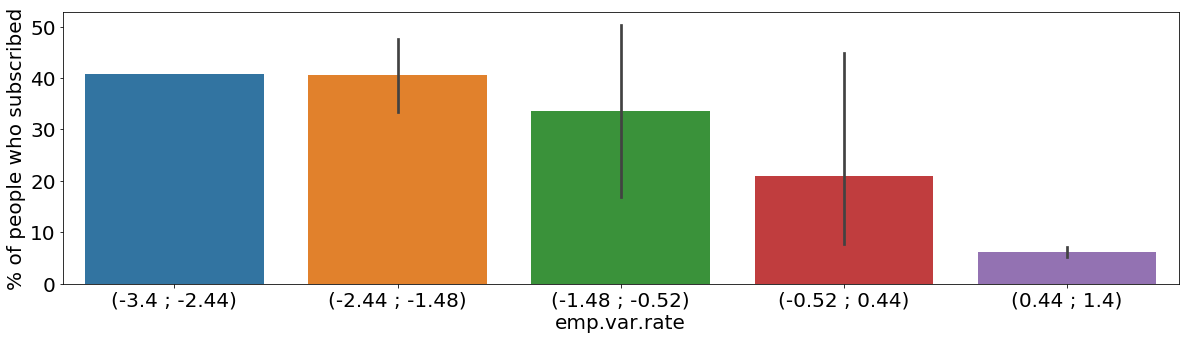

In [ ]:
column = data.columns[15]
print(column)

df = data[['y', column]]
df['y'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)
df = df.groupby(column).mean().reset_index()
df['y'] = df['y'].apply(lambda x: x * 100)

# assign range into a value. 
# For example if value = 3 and range_length = 5 then this function returns string '0 - 5'.
# if value = 6 and range_length = 5 then this function returns string '5 - 10'.
def assign_range(value, min_value, range_length):
    i = min_value
    while i < value:
        i += range_length
    if i > 0:
        return f'({round(i - range_length, 2)} ; {round(i, 2)})'
    else:
        return f'({round(i, 2)} ; {round(i + range_length, 2)})'
    
df[column] = df[column].apply(lambda x: assign_range(x, df[column].min(), (df[column].max() - df[column].min()) / 5))

fig, ax = plt.subplots(figsize = (20, 5))
sns.barplot(data = df, x = column, y = 'y')
# plt.xticks(rotation = 90)
plt.ylabel('% of people who subscribed', fontsize = 20)
plt.xlabel(column, fontsize = 20)
ax.tick_params(axis='both', labelsize = 20)

cons.price.idx


C:\Users\mbulk\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """


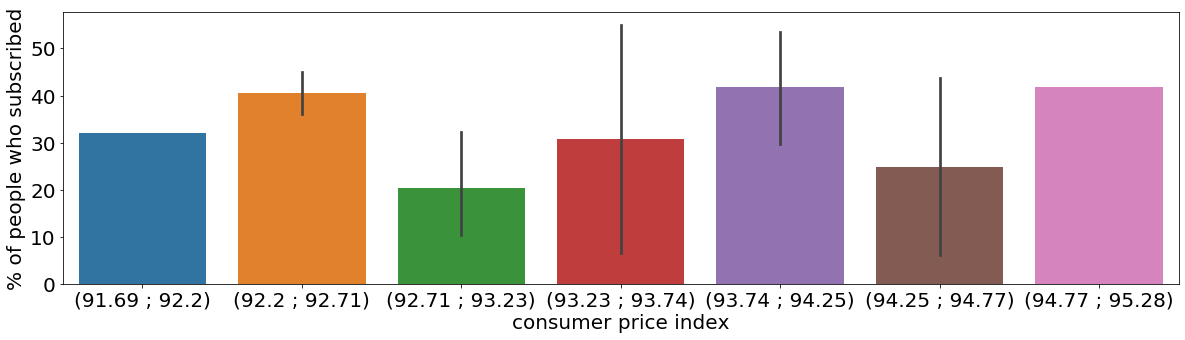

In [ ]:
column = data.columns[16]
print(column)

df = data[['y', column]]
df['y'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)
df = df.groupby(column).mean().reset_index()
df['y'] = df['y'].apply(lambda x: x * 100)

# assign range into a value. 
# For example if value = 3 and range_length = 5 then this function returns string '0 - 5'.
# if value = 6 and range_length = 5 then this function returns string '5 - 10'.
def assign_range(value, min_value, range_length):
    i = min_value
    while i < value:
        i += range_length
    if i > 0:
        return f'({round(i - range_length, 2)} ; {round(i, 2)})'
    else:
        return f'({round(i, 2)} ; {round(i + range_length, 2)})'
    
df[column] = df[column].apply(lambda x: assign_range(x, df[column].min(), (df[column].max() - df[column].min()) / 5))

fig, ax = plt.subplots(figsize = (20, 5))
sns.barplot(data = df, x = column, y = 'y')
# plt.xticks(rotation = 90)
plt.ylabel('% of people who subscribed', fontsize = 20)
plt.xlabel('consumer price index', fontsize = 20)
ax.tick_params(axis='both', labelsize = 20)

cons.conf.idx


C:\Users\mbulk\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """


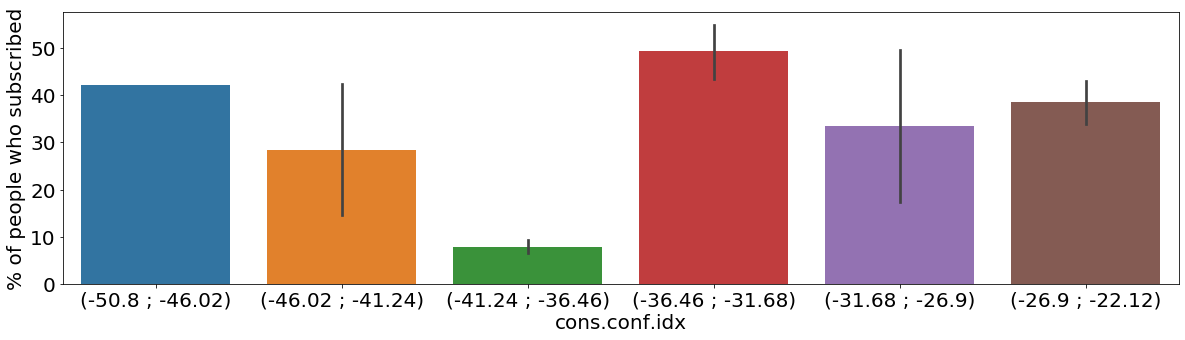

In [ ]:
column = data.columns[17]
print(column)

df = data[['y', column]]
df['y'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)
df = df.groupby(column).mean().reset_index()
df['y'] = df['y'].apply(lambda x: x * 100)

# assign range into a value. 
# For example if value = 3 and range_length = 5 then this function returns string '0 - 5'.
# if value = 6 and range_length = 5 then this function returns string '5 - 10'.
def assign_range(value, min_value, range_length):
    i = min_value
    while i < value:
        i += range_length
    if i > 0:
        return f'({round(i - range_length, 2)} ; {round(i, 2)})'
    else:
        return f'({round(i, 2)} ; {round(i + range_length, 2)})'
    
df[column] = df[column].apply(lambda x: assign_range(x, df[column].min(), (df[column].max() - df[column].min()) / 5))

fig, ax = plt.subplots(figsize = (20, 5))
sns.barplot(data = df, x = column, y = 'y')
# plt.xticks(rotation = 90)
plt.ylabel('% of people who subscribed', fontsize = 20)
plt.xlabel(column, fontsize = 20)
ax.tick_params(axis='both', labelsize = 20)

euribor3m


C:\Users\mbulk\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """


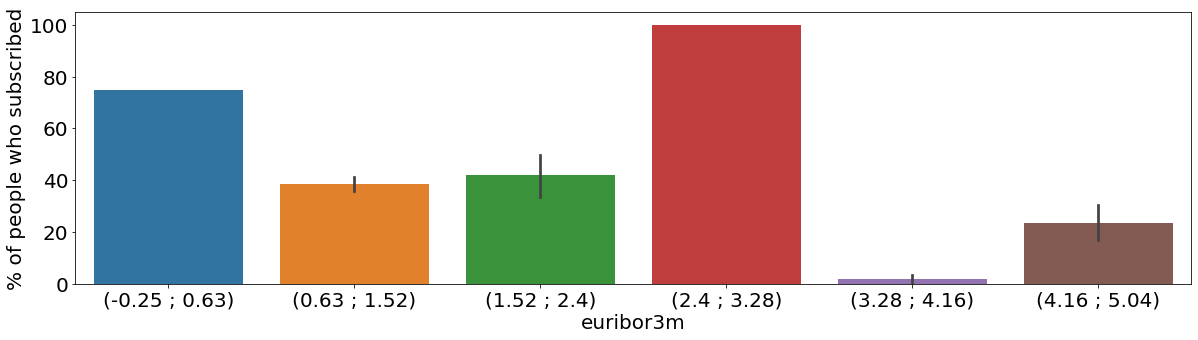

In [ ]:
column = data.columns[18]
print(column)

df = data[['y', column]]
df['y'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)
df = df.groupby(column).mean().reset_index()
df['y'] = df['y'].apply(lambda x: x * 100)

# assign range into a value. 
# For example if value = 3 and range_length = 5 then this function returns string '0 - 5'.
# if value = 6 and range_length = 5 then this function returns string '5 - 10'.
def assign_range(value, min_value, range_length):
    i = min_value
    while i < value:
        i += range_length
    if i > 0:
        return f'({round(i - range_length, 2)} ; {round(i, 2)})'
    else:
        return f'({round(i, 2)} ; {round(i + range_length, 2)})'
    
df[column] = df[column].apply(lambda x: assign_range(x, df[column].min(), (df[column].max() - df[column].min()) / 5))

fig, ax = plt.subplots(figsize = (20, 5))
sns.barplot(data = df, x = column, y = 'y')
# plt.xticks(rotation = 90)
plt.ylabel('% of people who subscribed', fontsize = 20)
plt.xlabel(column, fontsize = 20)
ax.tick_params(axis='both', labelsize = 20)

nr.employed


C:\Users\mbulk\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """


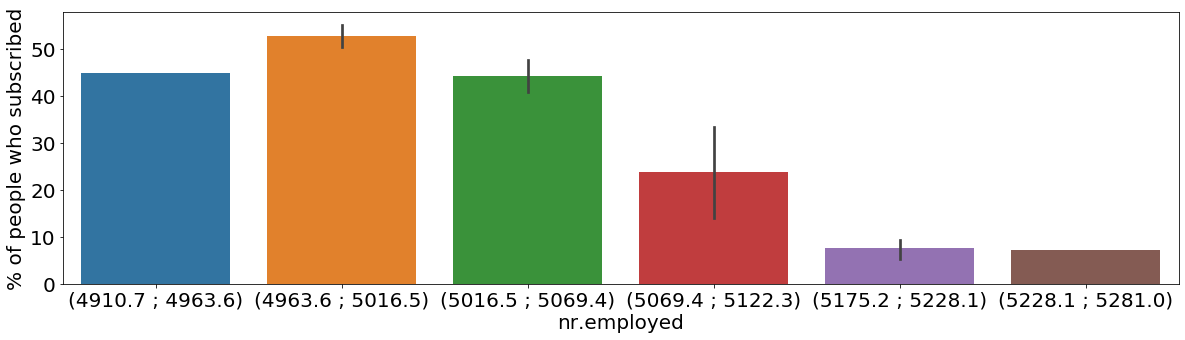

In [ ]:
column = data.columns[19]
print(column)

df = data[['y', column]]
df['y'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)
df = df.groupby(column).mean().reset_index()
df['y'] = df['y'].apply(lambda x: x * 100)

# assign range into a value. 
# For example if value = 3 and range_length = 5 then this function returns string '0 - 5'.
# if value = 6 and range_length = 5 then this function returns string '5 - 10'.
def assign_range(value, min_value, range_length):
    i = min_value
    while i < value:
        i += range_length
    if i > 0:
        return f'({round(i - range_length, 2)} ; {round(i, 2)})'
    else:
        return f'({round(i, 2)} ; {round(i + range_length, 2)})'
    
df[column] = df[column].apply(lambda x: assign_range(x, df[column].min(), (df[column].max() - df[column].min()) / 5))

fig, ax = plt.subplots(figsize = (20, 5))
sns.barplot(data = df, x = column, y = 'y')
# plt.xticks(rotation = 90)
plt.ylabel('% of people who subscribed', fontsize = 20)
plt.xlabel(column, fontsize = 20)
ax.tick_params(axis='both', labelsize = 20)